In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/cleaned/ipo_cleaned.csv')
print("Shape:", df.shape)
print("\nSubscription_Tier counts:")
print(df['Subscription_Tier'].value_counts())

Shape: (549, 19)

Subscription_Tier counts:
Subscription_Tier
Low       244
High      151
Medium    133
Under      21
Name: count, dtype: int64


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_2388\239884675.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


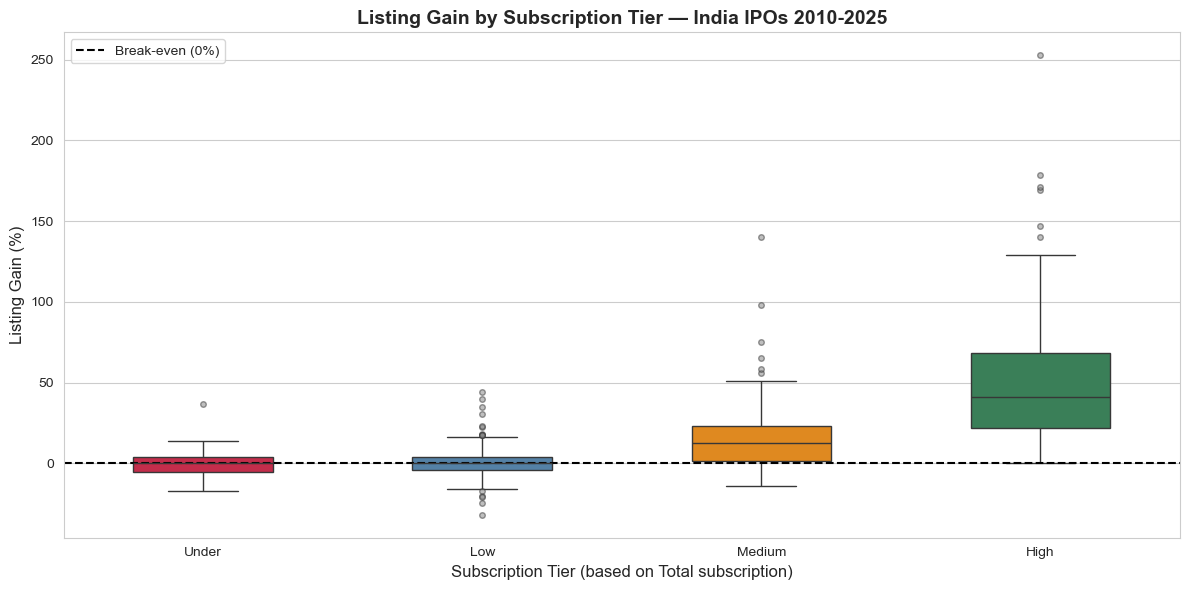

Chart saved.


In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, ax = plt.subplots()
# Order matters — Under to High left to right
tier_order = ['Under', 'Low', 'Medium', 'High']
sns.boxplot(
    data=df,
    x='Subscription_Tier',
    y='Listing Gain',
    order=tier_order,
    palette=['crimson', 'steelblue', 'darkorange', 'seagreen'],
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='gray',markersize=4, alpha=0.5),
    ax=ax
)
ax.axhline(y=0, color='black', linestyle='--',
           linewidth=1.5, label='Break-even (0%)')
ax.set_title('Listing Gain by Subscription Tier — India IPOs 2010-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Subscription Tier (based on Total subscription)', fontsize=12)
ax.set_ylabel('Listing Gain (%)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/08_subscription_tier_vs_listing_gain.png', dpi=150)
plt.show()
print("Chart saved.")

In [5]:
tier_summary = df.groupby('Subscription_Tier').agg(
    count          = ('IPO_Name', 'count'),
    avg_gain       = ('Listing Gain', 'mean'),
    median_gain    = ('Listing Gain', 'median'),
    pct_profitable = ('Listing Gain', lambda x: (x > 0).sum() / len(x) * 100),
    avg_qib        = ('QIB', 'mean'),
    avg_rii        = ('RII', 'mean')
).round(2)
tier_summary = tier_summary.reindex(['Under', 'Low', 'Medium', 'High'])
print(tier_summary)

                   count  avg_gain  median_gain  pct_profitable  avg_qib  \
Subscription_Tier                                                          
Under                 21      0.77         0.00           47.62     1.28   
Low                  244      0.74         0.00           48.77     4.67   
Medium               133     15.86        12.39           76.69    41.82   
High                 151     51.11        41.03           99.34   131.14   

                   avg_rii  
Subscription_Tier           
Under                 0.65  
Low                   2.85  
Medium               11.35  
High                 44.07  


In [ ]:
High tier IPOs (50x+ subscription) avg gain: 51.11%
Low tier IPOs (1-10x subscription) avg gain: 0.74%
That is a 50x difference in returns based on 
subscription level alone.

The most striking number: 99.34% of High tier IPOs 
were profitable on listing day. Out of 151 High 
subscription IPOs, only 1 gave a loss.

Under and Low tier IPOs had median gain of exactly 0% 
— meaning half of all low subscription IPOs gave 
zero or negative returns on listing day.

The box plot tells the full story visually:
Under and Low boxes sit right at the break-even line.
Medium box clearly above 0. High box towers above 
everything — median at 41% with upside to 250%+.

Connection to business question:
High subscription IPOs have avg QIB of 131x and 
avg RII of 44x. Institutions (QIB) are 3x more 
aggressive than retail in heavily subscribed IPOs.
This confirms QIB is the leading signal — when 
institutions go in hard, the IPO almost always 
delivers on listing day.